In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

print("Dataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

print("\nDataset Shape:")
print(df.shape)

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0]

print("\nPercentage of Missing Values:")
print(missing_percent)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None

Dataset Description:
         survived      pclass         age    

In [3]:

df = df.dropna(subset=["embarked", "embark_town"])


df["age"] = df["age"].fillna(df["age"].median())


df = df.drop(columns=["deck"])

print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


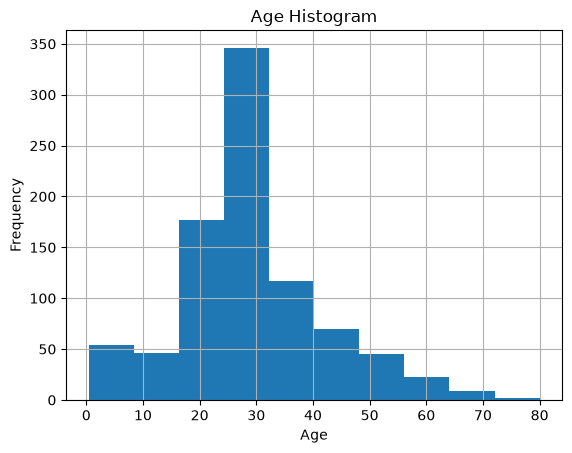

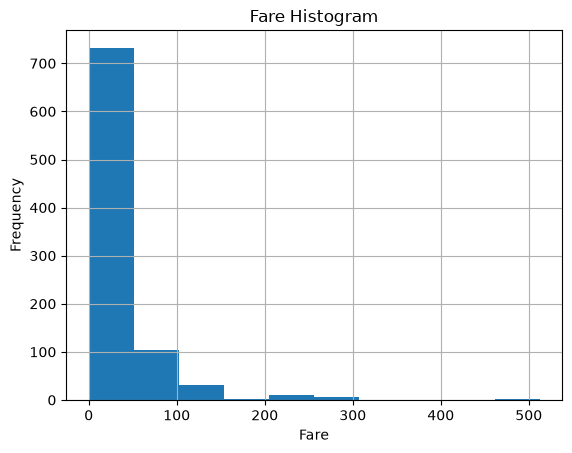

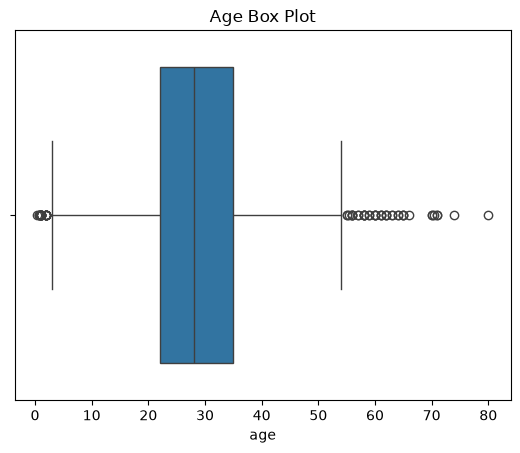

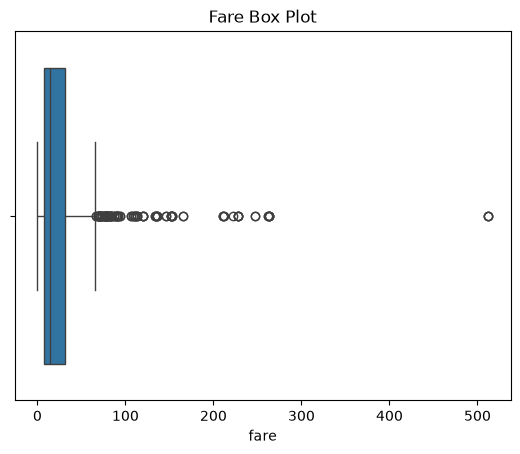

Age outliers: 65
Fare outliers: 114
Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


In [4]:

df["age"].hist()
plt.title("Age Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

df["fare"].hist()
plt.title("Fare Histogram")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


sns.boxplot(x=df["age"])
plt.title("Age Box Plot")
plt.show()

sns.boxplot(x=df["fare"])
plt.title("Fare Box Plot")
plt.show()


Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[(df["age"] < lower_age) | (df["age"] > upper_age)]

print("Age outliers:", len(age_outliers))


Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[(df["fare"] < lower_fare) | (df["fare"] > upper_fare)]

print("Fare outliers:", len(fare_outliers))

mean_fare = df["fare"].mean()
median_fare = df["fare"].median()
mode_fare = df["fare"].mode()[0]

print("Fare mean:", mean_fare)
print("Fare median:", median_fare)
print("Fare mode:", mode_fare)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154
Class 1 survival rate: 0.6261682242990654
Class 2 survival rate: 0.47282608695652173
Class 3 survival rate: 0.24236252545824846

Male:
Class 1: 0.36885245901639346
Class 2: 0.1574074074074074
Class 3: 0.13544668587896252

Female:
Class 1: 0.967391304347826
Class 2: 0.9210526315789473
Class 3: 0.5
Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


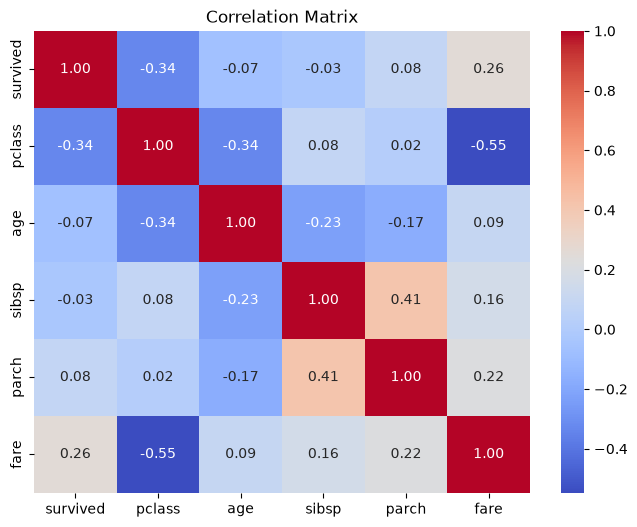


Two strongest correlations:
pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


In [5]:

male_mask = (df["sex"] == "male") | (df["sex"] == "male")
female_mask = (df["sex"] == "female") | (df["sex"] == "female")

print("Male survival rate:", df[male_mask]["survived"].mean())
print("Female survival rate:", df[female_mask]["survived"].mean())


class1_mask = (df["pclass"] == 1) | (df["pclass"] == 1)
class2_mask = (df["pclass"] == 2) | (df["pclass"] == 2)
class3_mask = (df["pclass"] == 3) | (df["pclass"] == 3)

print("Class 1 survival rate:", df[class1_mask]["survived"].mean())
print("Class 2 survival rate:", df[class2_mask]["survived"].mean())
print("Class 3 survival rate:", df[class3_mask]["survived"].mean())


male_class1 = (df["sex"] == "male") & (df["pclass"] == 1)
male_class2 = (df["sex"] == "male") & (df["pclass"] == 2)
male_class3 = (df["sex"] == "male") & (df["pclass"] == 3)

female_class1 = (df["sex"] == "female") & (df["pclass"] == 1)
female_class2 = (df["sex"] == "female") & (df["pclass"] == 2)
female_class3 = (df["sex"] == "female") & (df["pclass"] == 3)

print("\nMale:")
print("Class 1:", df[male_class1]["survived"].mean())
print("Class 2:", df[male_class2]["survived"].mean())
print("Class 3:", df[male_class3]["survived"].mean())

print("\nFemale:")
print("Class 1:", df[female_class1]["survived"].mean())
print("Class 2:", df[female_class2]["survived"].mean())
print("Class 3:", df[female_class3]["survived"].mean())


cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[cols].corr()

print("Correlation Matrix:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

strongest = upper.abs().stack().sort_values(ascending=False)

print("\nTwo strongest correlations:")
print(strongest.head(2))

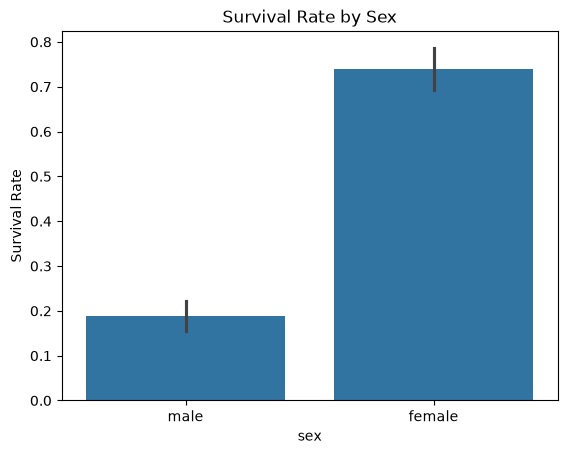

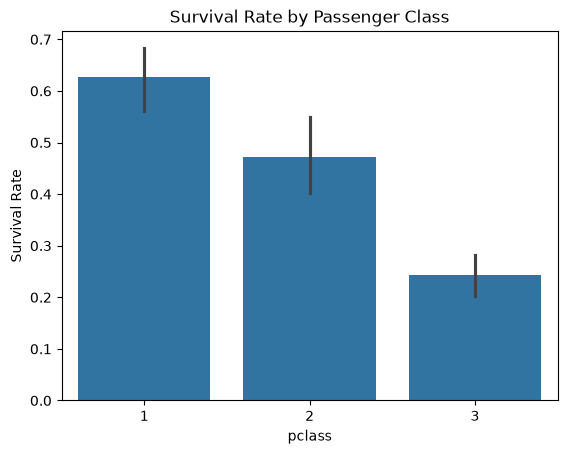

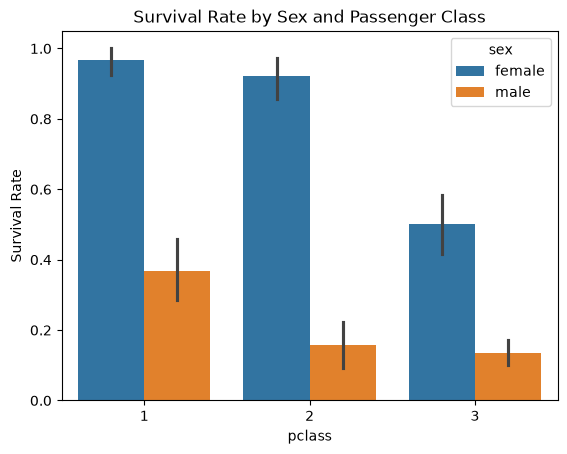

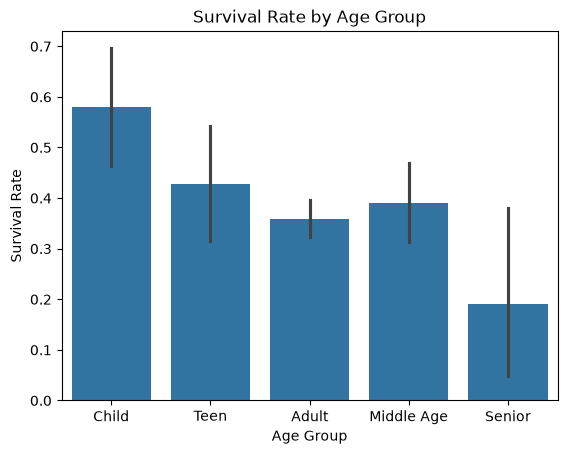

In [6]:

sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()


sns.barplot(data=df, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 40, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle Age", "Senior"]
)

sns.barplot(data=df, x="age_group", y="survived")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

In [7]:

columns = ["age", "fare"]

print("Before standardization:")
print(df[columns].agg(["mean", "std"]))

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[columns] = scaler.fit_transform(df[columns])


print("\nAfter standardization:")
print(df_scaled[columns].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
